`01_study_ds.ipynb`: en el notebook actual se procederá a estudiar el dataset descargado procedente de [AnimalTrack: A Benchmark for Multi-Animal Tracking in the Wild](https://hengfan2010.github.io/projects/AnimalTrack/download.html) del cual solo se filtró por tres clases: "horse", "pig" and "penguin".

# Importaciones

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from dataset.scanner import scan_raw_dataset
from dataset.analyzer import generate_dataset_summary, parse_annotations
from utils.file_utils import load_gt
PROJECT_ROOT = Path().resolve().parent
CONFIG_PATH = PROJECT_ROOT / "paths.yaml"

# Estudio del dataset

El dataset se encuentra dentro de la carpeta `dataset` y hay una carpeta por cada animal seleccionado. Dentro de cada carpeta hay dos subcarpetas: `videos` y `gt`. 
- `videos`: contiene los videos de los animales en formato ".mp4".
- `gt`: contiene los ground truth de los videos en formato ".txt".

Cada video con nombre "ejemplo.mp4" tiene un ground truth con nombre "ejemplo_gt.txt". Por otro lado en el dataset se informa del formato de las etiquetas, cada línea del archivo .txt tiene el siguiente formato:

`[frame_id, target_id, top_left_x, top_left_y, width, confidence, class, visibility]`

## Importación del dataset

Se ha definido la función `get_ds_paths` del cual se obtiene la ruta del dataset y posteriormente por cada una de las clases se crean pares de rutas relacionando las rutas de los videos y de los ground truths.

In [2]:
ds_info = scan_raw_dataset(CONFIG_PATH)

In [3]:
print(f'Ruta del dataset raw: {ds_info["raw_path"]}')
print(f"Número de clases: {len(ds_info['classes'])}")
print("Clases mapeadas:")
for label, class_id in ds_info['classes'].items():
    print(f"- {label} (ID: {class_id})")

Ruta del dataset raw: /home/cgonzalez/Object_Recognition/dataset/raw
Número de clases: 3
Clases mapeadas:
- horse (ID: 6)
- penguin (ID: 7)
- pig (ID: 8)


Ejemplo de una ruta de videos y gt

In [4]:
example = ds_info['data']['horse'][0]
print(f"Video: {example['video']}")
print(f"Label: {example['label']}")

Video: /home/cgonzalez/Object_Recognition/dataset/raw/horse/videos/horse_1.mp4
Label: /home/cgonzalez/Object_Recognition/dataset/raw/horse/gt/horse_1_gt.txt


## Análisis de los datos

Utilizamos `generate_dataset_summary` para crear un DataFrame que consolida la información de todos los videos y sus anotaciones.

In [5]:
df_summary = generate_dataset_summary(ds_info)
df_summary

,video_name,class_name,frame_id,object_count,width,height,total_frames,fps,duration_sec
0,horse_1,horse,1,29,2560,1440,284,30.0,9.466667
1,horse_1,horse,2,29,2560,1440,284,30.0,9.466667
2,horse_1,horse,3,29,2560,1440,284,30.0,9.466667
3,horse_1,horse,4,29,2560,1440,284,30.0,9.466667
4,horse_1,horse,5,29,2560,1440,284,30.0,9.466667
...,...,...,...,...,...,...,...,...,...
7559,pig_5,pig,314,12,2560,1440,318,30.0,10.600000
7560,pig_5,pig,315,12,2560,1440,318,30.0,10.600000
7561,pig_5,pig,316,12,2560,1440,318,30.0,10.600000
7562,pig_5,pig,317,12,2560,1440,318,30.0,10.600000


Extraer el número de videos por clase, uy el número de frames por video

/tmp/ipykernel_3806653/2118309930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=videos_por_clase, x='class_name', y='total_videos', ax=ax1, palette='magma')


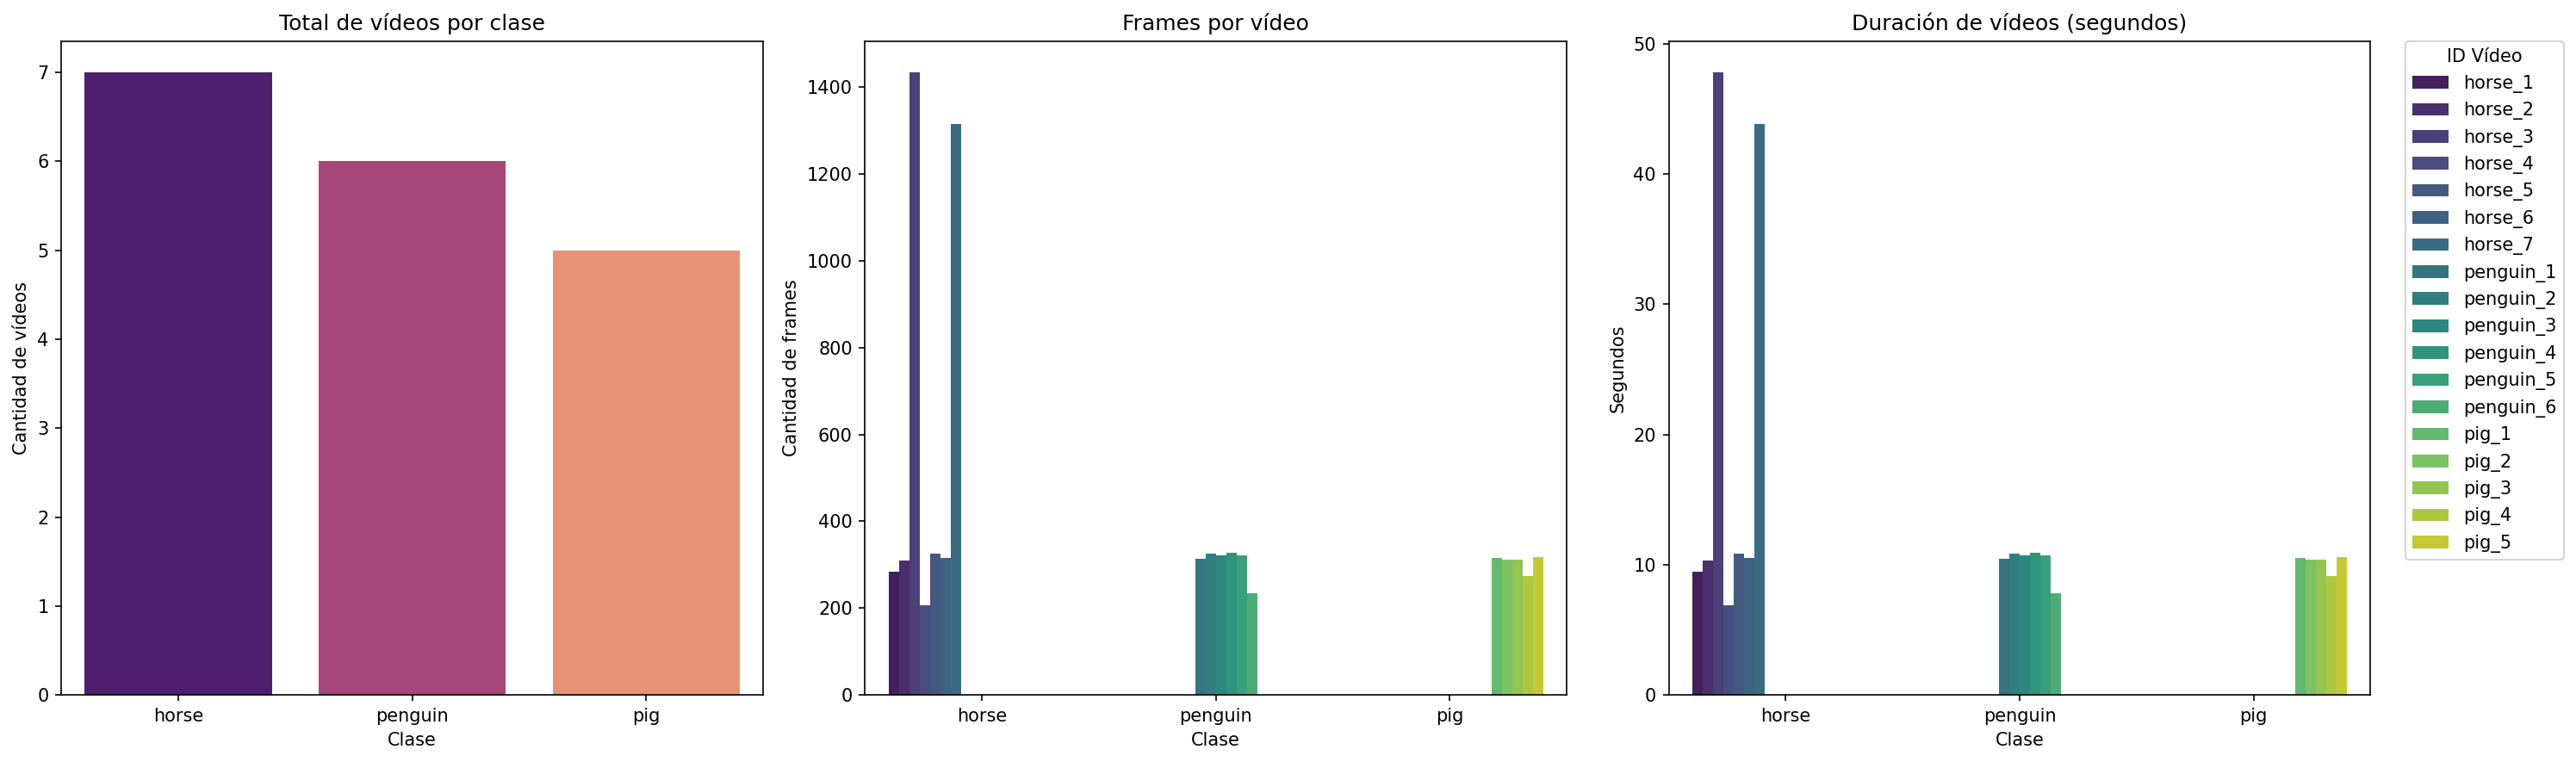

In [20]:
videos_por_clase = df_summary.groupby('class_name')['video_name'].nunique().reset_index(name='total_videos')
frames_por_video = df_summary.groupby(['class_name', 'video_name']).size().reset_index(name='count')
duracion_videos = df_summary.groupby(['class_name', 'video_name'])['duration_sec'].first().reset_index()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

sns.barplot(data=videos_por_clase, x='class_name', y='total_videos', ax=ax1, palette='magma')
ax1.set_title('Total de vídeos por clase')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Cantidad de vídeos')

sns.barplot(data=frames_por_video, x='class_name', y='count', hue='video_name', ax=ax2, palette='viridis')
ax2.set_title('Frames por vídeo')
ax2.set_xlabel('Clase')
ax2.set_ylabel('Cantidad de frames')
ax2.get_legend().remove() 

sns.barplot(data=duracion_videos, x='class_name', y='duration_sec', hue='video_name', ax=ax3, palette='viridis')
ax3.set_title('Duración de vídeos (segundos)')
ax3.set_xlabel('Clase')
ax3.set_ylabel('Segundos')

ax3.legend(title='ID Vídeo', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig(f'docs/images/images_dsitribution.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()

## Inspección de las Anotaciones

Cargamos un archivo crudo y aplicamos nuestra función de parseo para ver la estructura.

In [7]:
video_path = example['video']
label_path = example['label']

gt_raw = load_gt(label_path)
print("Formato crudo:")
gt_raw[:3]

Formato crudo:


[[1, 1, 437, 359, 651, 735, 1, 6, -1],
 [1, 2, 78, 465, 340, 517, 1, 6, -1],
 [1, 3, 1515, 344, 430, 467, 1, 6, -1]]

Estructura:

In [8]:
gt_data = parse_annotations(gt_raw)
print("\nFormato estructurado:")
gt_data[:2]


Formato estructurado:


[{'frame_id': 1,
  'target_id': 1,
  'top_left_x': 437,
  'top_left_y': 359,
  'width': 651,
  'height': 735,
  'confidence': 1,
  'class_id': 6,
  'visibility': -1},
 {'frame_id': 1,
  'target_id': 2,
  'top_left_x': 78,
  'top_left_y': 465,
  'width': 340,
  'height': 517,
  'confidence': 1,
  'class_id': 6,
  'visibility': -1}]